In [1]:
#!pip install matplotlib


In [2]:
#!pip install scikit-learn


In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import shap


c:\Users\chukw\anaconda3\envs\llm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv(r"C:\Users\chukw\Documents\RAIN\AIML 2ND SEMESTER (File responses)\Rain Class\Week 11 Explainable AI\Explainable AI - Dataset.csv")

In [5]:
df.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
0,YAK/S/00001,Commercial Sales and Marketing,"MSc, MBA and PhD",Female,Direct Internal process,2,1986,12.5,2011,1,0,41,ANAMBRA,No,Married,No,No,0,0
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,0,52,ANAMBRA,Yes,Married,No,No,0,0
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,0,42,KATSINA,Yes,Married,No,No,0,0
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0


In [6]:
df.columns

Index(['EmployeeNo', 'Division', 'Qualification', 'Gender',
       'Channel_of_Recruitment', 'Trainings_Attended', 'Year_of_birth',
       'Last_performance_score', 'Year_of_recruitment', 'Targets_met',
       'Previous_Award', 'Training_score_average', 'State_Of_Origin',
       'Foreign_schooled', 'Marital_Status', 'Past_Disciplinary_Action',
       'Previous_IntraDepartmental_Movement', 'No_of_previous_employers',
       'Promoted_or_Not'],
      dtype='object')

In [7]:
X = df[['Trainings_Attended', 'Last_performance_score', 'Targets_met','Previous_Award','Training_score_average','Past_Disciplinary_Action']]
y = df['Promoted_or_Not']


In [8]:
X["Past_Disciplinary_Action"].value_counts()

Past_Disciplinary_Action
No     38161
Yes      151
Name: count, dtype: int64

In [9]:
#Get dummies used to get one hot encoded values
X = pd.get_dummies(X, columns = ["Past_Disciplinary_Action"],drop_first = True , dtype = int)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size = 0.3, random_state=12)
dtc = DecisionTreeClassifier(random_state=1)

In [11]:
dtc.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
dtc.score(X_train,y_train)

0.9316503840704005

In [13]:
dtc.score(X_test,y_test)

0.9231773099008178

In [14]:
dtc.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(11494,))

In [15]:
dtc.predict(X_train[-4:-3])

array([0])

In [16]:
X_train[-4:-3]

,Trainings_Attended,Last_performance_score,Targets_met,Previous_Award,Training_score_average,Past_Disciplinary_Action_Yes
9475,2,7.5,0,0,51,0


In [17]:
dtc.predict_proba(X_train[-4:-3])

array([[0.97590361, 0.02409639]])

In [18]:
#Base Value is the average probality(predictictions) of the train data
dtc.predict_proba(X_train)

array([[0.97590361, 0.02409639],
       [1.        , 0.        ],
       [0.84375   , 0.15625   ],
       ...,
       [1.        , 0.        ],
       [0.93      , 0.07      ],
       [0.92045455, 0.07954545]], shape=(26818, 2))

In [19]:
dtc.predict_proba(X_train).mean(axis=0)

array([0.91494519, 0.08505481])

In [20]:
shap.TreeExplainer?

Init signature:
shap.TreeExplainer(
    model,
    data=None,
    model_output='raw',
    feature_perturbation='auto',
    feature_names=None,
    approximate=<object object at 0x0000024A69D659E0>,
    link=None,
    linearize_link=None,
)
Docstring:     
Uses Tree SHAP algorithms to explain the output of ensemble tree models.

Tree SHAP is a fast and exact method to estimate SHAP values for tree models
and ensembles of trees, under several different possible assumptions about
feature dependence. It depends on fast C++ implementations either inside an
external model package or in the local compiled C extension.

Examples
--------
See `Tree explainer examples <https://shap.readthedocs.io/en/latest/api_examples/explainers/Tree.html>`_
Init docstring:
Build a new Tree explainer for the passed model.

Parameters
----------
model : model object
    The tree based machine learning model that we want to explain.
    XGBoost, LightGBM, CatBoost, Pyspark and most tree-based
    scikit-learn mod

In [21]:
print(np.__version__)
print(shap.__version__)

2.2.6
0.49.1


In [ ]:
#summary plot is best suited for global interpretation
explainer = shap.TreeExplainer(dtc, X_train,feature_names = X.columns)

In [23]:
explainer.expected_value

array([0.91538103, 0.08461897])

In [24]:
base_value = explainer.expected_value[1]

In [25]:
base_value

np.float64(0.08461897377585043)

In [26]:
explainer.shap_values(X_train)

array([[[-0.0044413 ,  0.0044413 ],
        [ 0.00316305, -0.00316304],
        [ 0.03171466, -0.03171466],
        [ 0.01431497, -0.01431497],
        [ 0.01577124, -0.01577123],
        [ 0.        ,  0.        ]],

       [[-0.00357175,  0.00357175],
        [ 0.00957853, -0.00957853],
        [ 0.02560022, -0.02560022],
        [ 0.00752412, -0.00752412],
        [ 0.04548785, -0.04548786],
        [ 0.        ,  0.        ]],

       [[-0.00113967,  0.00113967],
        [-0.01022594,  0.01022594],
        [-0.0722512 ,  0.0722512 ],
        [ 0.01163123, -0.01163123],
        [ 0.00035455, -0.00035455],
        [ 0.        ,  0.        ]],

       ...,

       [[-0.00277606,  0.00277606],
        [ 0.00820524, -0.00820523],
        [ 0.02047872, -0.02047872],
        [ 0.00951262, -0.00951262],
        [ 0.04853565, -0.04853566],
        [ 0.00066281, -0.00066281]],

       [[-0.00593723,  0.00593723],
        [ 0.02383923, -0.02383924],
        [ 0.02171193, -0.02171193],
       

In [27]:
# WHen worling with 2d arrays depthgoes first =, then rows then columns
shap_values = explainer.shap_values(X_train)[:,:,1]
shap_values

array([[ 0.0044413 , -0.00316304, -0.03171466, -0.01431497, -0.01577123,
         0.        ],
       [ 0.00357175, -0.00957853, -0.02560022, -0.00752412, -0.04548786,
         0.        ],
       [ 0.00113967,  0.01022594,  0.0722512 , -0.01163123, -0.00035455,
         0.        ],
       ...,
       [ 0.00277606, -0.00820523, -0.02047872, -0.00951262, -0.04853566,
        -0.00066281],
       [ 0.00593723, -0.02383924, -0.02171193, -0.01293216,  0.03792712,
         0.        ],
       [ 0.00779748, -0.01705841, -0.00708804, -0.01946035,  0.03073581,
         0.        ]], shape=(26818, 6))

In [28]:
pd.DataFrame(data = shap_values, columns = [f"shapely_{i}"for  i in X.columns])

,shapely_Trainings_Attended,shapely_Last_performance_score,shapely_Targets_met,shapely_Previous_Award,shapely_Training_score_average,shapely_Past_Disciplinary_Action_Yes
0,0.004441,-0.003163,-0.031715,-0.014315,-0.015771,0.000000
1,0.003572,-0.009579,-0.025600,-0.007524,-0.045488,0.000000
2,0.001140,0.010226,0.072251,-0.011631,-0.000355,0.000000
3,0.003459,-0.002506,0.069714,-0.000053,0.055294,0.000000
4,0.002915,-0.013395,-0.024403,-0.007620,-0.008782,0.000000
...,...,...,...,...,...,...
26813,-0.027628,-0.044291,0.058685,-0.005695,-0.065690,0.000000
26814,0.004441,-0.003163,-0.031715,-0.014315,-0.015771,0.000000
26815,0.002776,-0.008205,-0.020479,-0.009513,-0.048536,-0.000663
26816,0.005937,-0.023839,-0.021712,-0.012932,0.037927,0.000000


In [29]:
X_train

,Trainings_Attended,Last_performance_score,Targets_met,Previous_Award,Training_score_average,Past_Disciplinary_Action_Yes
9440,2,7.5,0,0,51,0
21954,2,7.5,0,0,41,0
4173,2,7.5,1,0,78,0
34583,2,10.0,1,0,57,0
5047,2,5.0,0,0,71,0
...,...,...,...,...,...,...
12108,2,0.0,1,0,49,0
9475,2,7.5,0,0,51,0
36482,2,7.5,0,0,42,1
19709,2,7.5,0,0,62,0


In [30]:
explainer.shap_values(X_train.iloc[0])

array([[-0.0044413 ,  0.0044413 ],
       [ 0.00316305, -0.00316304],
       [ 0.03171466, -0.03171466],
       [ 0.01431497, -0.01431497],
       [ 0.01577124, -0.01577123],
       [ 0.        ,  0.        ]])

In [31]:
shap_values[0]

array([ 0.0044413 , -0.00316304, -0.03171466, -0.01431497, -0.01577123,
        0.        ])

In [32]:
shap.initjs()

In [33]:
d = pd.DataFrame()
d["Features"]= X.columns
d["Score"]= dtc.feature_importances_
d.sort_values(by = "Score", ascending=False)

,Features,Score
4,Training_score_average,0.587988
2,Targets_met,0.144782
1,Last_performance_score,0.099984
3,Previous_Award,0.089889
0,Trainings_Attended,0.071511
5,Past_Disciplinary_Action_Yes,0.005846


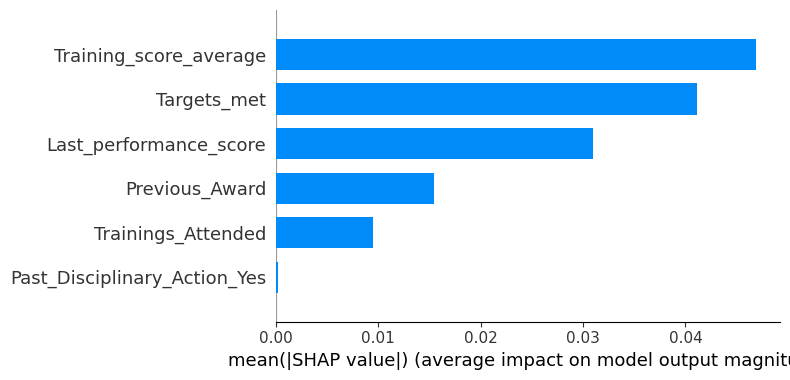

In [34]:
shap.summary_plot(shap_values,X_train,feature_names = X.columns,plot_type = 'bar')

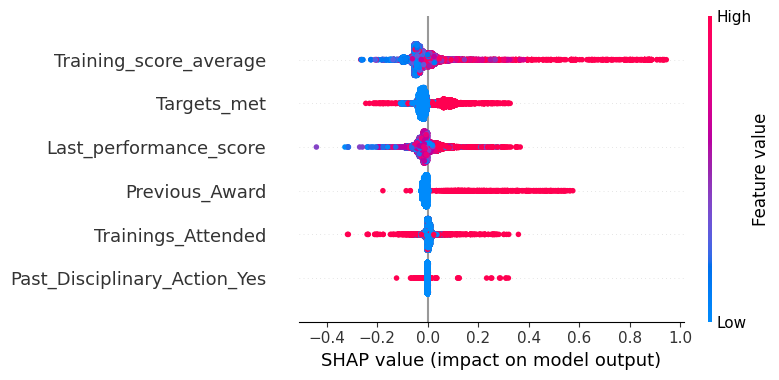

In [35]:
shap.summary_plot(shap_values, X_train,feature_names=X.columns)

In [36]:
#force plot is best for local   interpretation
shap.force_plot(base_value, shap_values[0],X_train[0:1],X.columns)

In [42]:
shap.force_plot(base_value, shap_values[-1], X_train.iloc[-1], X.columns)


In [46]:
shap.force_plot(base_value,shap_values[0:15],X_train[0:15],X.columns)

In [47]:

shap.force_plot(base_value,shap_values[15],X_train[15:16],X.columns)

In [48]:
print(X.columns)
shap_values[15]

Index(['Trainings_Attended', 'Last_performance_score', 'Targets_met',
       'Previous_Award', 'Training_score_average',
       'Past_Disciplinary_Action_Yes'],
      dtype='object')


array([ 0.00212759,  0.02846912,  0.03350176, -0.00783766,  0.85912021,
        0.        ])

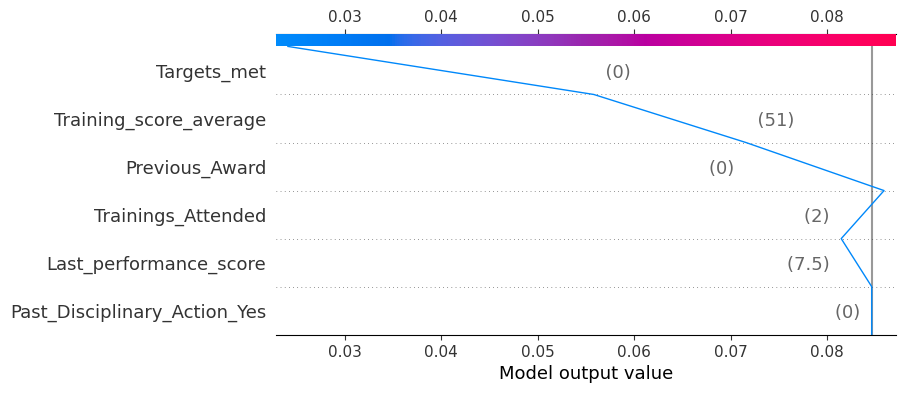

In [51]:
shap.decision_plot(base_value,shap_values[0], features = X_train[0:1],feature_names = list(X.columns))

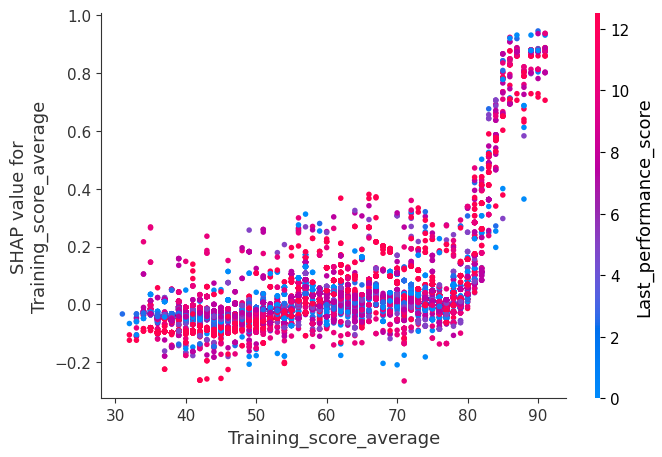

In [54]:
shap.dependence_plot(ind = "Training_score_average",shap_values=shap_values,features = X_train,feature_names=X.columns,interaction_index = "auto")

# DEEP EXPLAINERS